# Modelo No. 2

## 1. Importaciones y utilidades

In [22]:
import os
import cv2
import numpy as np
from datetime import datetime
import mediapipe as mp
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.regularizers import l2
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from keras.models import load_model
from mediapipe.python.solutions.holistic import Holistic
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import json

ROOT_PATH = "data"
FRAME_ACTIONS_PATH = "frases"  # carpeta por palabra/frase
FONT = cv2.FONT_HERSHEY_SIMPLEX
FONT_SIZE = 1
FONT_POS = (10, 30)

# Crear carpeta si no existe
def create_folder(path):
    if not os.path.exists(path):
        os.makedirs(path)

# Detectar si hay manos en los resultados
def there_hand(results):
    return results.left_hand_landmarks or results.right_hand_landmarks

# Dibujar los keypoints de las manos
def draw_keypoints(image, results):
    if results.left_hand_landmarks:
        mp.solutions.drawing_utils.draw_landmarks(image, results.left_hand_landmarks, mp.solutions.holistic.HAND_CONNECTIONS)
    if results.right_hand_landmarks:
        mp.solutions.drawing_utils.draw_landmarks(image, results.right_hand_landmarks, mp.solutions.holistic.HAND_CONNECTIONS)

# Aplicar MediaPipe
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    results = model.process(image)
    return results

# Extraer keypoints de ambas manos
def extract_keypoints(results):
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21 * 3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21 * 3)
    return np.concatenate([lh, rh])

## 2. Captura de muestras

In [17]:
def capture_samples_npy(path, margin_frame=1, min_cant_frames=30, delay_frames=3):
    """
    CAPTURA DE MUESTRAS PARA UNA PALABRA Y GUARDA KEYPOINTS COMO .NPY
    - Comienza a grabar cuando detecta mano.
    - Sigue 'delay_frames' tras dejar de ver la mano, para no cortar brusco.
    - Recorta 'margin_frame' al inicio y 'delay_frames' al final ANTES de guardar.
    """
    create_folder(path)

    registro_actual = len([f for f in os.listdir(path) if f.endswith(".npy")]) + 1

    cap = cv2.VideoCapture(1)  # 0 suele ser la cámara principal (cambia si usas 1)
    window_name = "Vista previa de señas"
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(window_name, 800, 600)

    DISPLAY_WIDTH, DISPLAY_HEIGHT = 800, 600

    recording = False
    sequence = []
    count_frame = 0
    fix_frames = 0  # cuenta frames desde que se perdió la mano

    try:
        with mp.solutions.holistic.Holistic(min_detection_confidence=0.5,
                                            min_tracking_confidence=0.5) as holistic_model:
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break

                image = frame.copy()
                results = mediapipe_detection(frame, holistic_model)
                hand_present = there_hand(results)

                if hand_present:
                    # Si volvimos a ver la mano, resetea el contador de "perdida"
                    fix_frames = 0

                    # Si no estaba grabando, inicia
                    if not recording:
                        recording = True
                        sequence = []
                        count_frame = 0

                    count_frame += 1

                    # Mostrar estado
                    cv2.putText(image, f'Registro {registro_actual}...', (10, 30), FONT, FONT_SIZE, (100, 200, 255), 2)
                    cv2.putText(image, 'Capturando...', (20, image.shape[0] - 20), FONT, FONT_SIZE, (0, 50, 255), 2)

                    # A partir del margen inicial, acumulamos keypoints
                    if count_frame > margin_frame:
                        keypoints = extract_keypoints(results)
                        if keypoints is not None:
                            sequence.append(keypoints)

                elif recording:
                    # Se perdió la mano pero seguimos unos frames por "delay"
                    fix_frames += 1
                    cv2.putText(image, f'Registro {registro_actual}...', (10, 30), FONT, FONT_SIZE, (100, 200, 255), 2)
                    cv2.putText(image, f'Finalizando... ({fix_frames}/{delay_frames})', (20, image.shape[0] - 20),
                                FONT, FONT_SIZE, (0, 165, 255), 2)

                    if fix_frames >= delay_frames:
                        # Recorte final: quitamos 'delay_frames' al final y 'margin_frame' (ya no agregamos durante margen, pero por seguridad)
                        if delay_frames > 0 and len(sequence) > delay_frames:
                            sequence = sequence[:-delay_frames]

                        # Validar longitud mínima
                        if len(sequence) >= min_cant_frames:
                            timestamp = datetime.now().strftime('%y%m%d%H%M%S%f')
                            npy_path = os.path.join(path, f'sample_{timestamp}.npy')
                            np.save(npy_path, np.array(sequence))
                            print(f"✅ Muestra guardada: {npy_path}")
                            registro_actual += 1
                        else:
                            print("⚠️ Muestra descartada por ser muy corta.")

                        # Reset total
                        recording = False
                        sequence = []
                        count_frame = 0
                        fix_frames = 0

                else:
                    # No se está grabando y no hay mano: estado en espera
                    cv2.putText(image, f'Registro {registro_actual}...', (10, 30), FONT, FONT_SIZE, (100, 200, 255), 2)
                    cv2.putText(image, 'Listo para capturar...', (20, image.shape[0] - 20),
                                FONT, FONT_SIZE, (0, 220, 100), 2)

                # Dibujo y display
                draw_keypoints(image, results)
                image_display = cv2.resize(image, (DISPLAY_WIDTH, DISPLAY_HEIGHT))
                cv2.imshow(window_name, image_display)

                # Salir
                if cv2.waitKey(10) & 0xFF == ord('q'):
                    break
    finally:
        cap.release()
        cv2.destroyAllWindows()

if __name__ == "__main__":
    palabra = "gracias"
    word_path = os.path.join(ROOT_PATH, FRAME_ACTIONS_PATH, palabra)
    capture_samples_npy(word_path)

✅ Muestra guardada: data\frases\gracias\sample_250911182531253620.npy
⚠️ Muestra descartada por ser muy corta.
⚠️ Muestra descartada por ser muy corta.
⚠️ Muestra descartada por ser muy corta.
⚠️ Muestra descartada por ser muy corta.
⚠️ Muestra descartada por ser muy corta.
⚠️ Muestra descartada por ser muy corta.
✅ Muestra guardada: data\frases\gracias\sample_250911182551699380.npy
✅ Muestra guardada: data\frases\gracias\sample_250911182557178399.npy
⚠️ Muestra descartada por ser muy corta.
⚠️ Muestra descartada por ser muy corta.
⚠️ Muestra descartada por ser muy corta.
⚠️ Muestra descartada por ser muy corta.
✅ Muestra guardada: data\frases\gracias\sample_250911182609652599.npy
✅ Muestra guardada: data\frases\gracias\sample_250911182614874931.npy
✅ Muestra guardada: data\frases\gracias\sample_250911182619535981.npy
✅ Muestra guardada: data\frases\gracias\sample_250911182624444462.npy
✅ Muestra guardada: data\frases\gracias\sample_250911182629309559.npy
✅ Muestra guardada: data\frase

## 3. Normalización

In [18]:
ROOT_PATH = "data"
FRAME_ACTIONS_PATH = "frases"
MODEL_FRAMES = 30  

def normalize_keypoints_sequence(sequence, target_len=30):
    current_len = len(sequence)
    if current_len == target_len:
        return sequence
    elif current_len > target_len:
        # Reducir seleccionando frames uniformemente
        step = current_len / target_len
        indices = np.arange(0, current_len, step).astype(int)[:target_len]
        return sequence[indices]
    else:
        # Interpolar si es menor
        indices = np.linspace(0, current_len - 1, target_len)
        interpolated = []
        for i in indices:
            lower = int(np.floor(i))
            upper = int(np.ceil(i))
            weight = i - lower
            if upper >= current_len:
                upper = current_len - 1
            interpolated_frame = (1 - weight) * sequence[lower] + weight * sequence[upper]
            interpolated.append(interpolated_frame)
        return np.array(interpolated)

def process_npy_directory(word_directory, target_len=30):
    for fname in os.listdir(word_directory):
        if fname.endswith(".npy"):
            full_path = os.path.join(word_directory, fname)
            sequence = np.load(full_path)
            normalized = normalize_keypoints_sequence(sequence, target_len)
            np.save(full_path, normalized)
            print(f"✅ Normalizado: {fname} → {normalized.shape}")

if __name__ == "__main__":
    word_ids = [w for w in os.listdir(os.path.join(ROOT_PATH, FRAME_ACTIONS_PATH))]

    for word_id in word_ids:
        word_path = os.path.join(ROOT_PATH, FRAME_ACTIONS_PATH, word_id)
        if os.path.isdir(word_path):
            print(f"\n📦 Normalizando muestras de: {word_id}")
            process_npy_directory(word_path, target_len=MODEL_FRAMES)


📦 Normalizando muestras de: adios
✅ Normalizado: sample_250911173514093009.npy → (30, 126)
✅ Normalizado: sample_250911173518505603.npy → (30, 126)
✅ Normalizado: sample_250911173522246092.npy → (30, 126)
✅ Normalizado: sample_250911173526969190.npy → (30, 126)
✅ Normalizado: sample_250911173531286471.npy → (30, 126)
✅ Normalizado: sample_250911173535634534.npy → (30, 126)
✅ Normalizado: sample_250911173540405201.npy → (30, 126)
✅ Normalizado: sample_250911173544863093.npy → (30, 126)
✅ Normalizado: sample_250911173549505823.npy → (30, 126)
✅ Normalizado: sample_250911173555224834.npy → (30, 126)
✅ Normalizado: sample_250911173559660009.npy → (30, 126)
✅ Normalizado: sample_250911173603810097.npy → (30, 126)
✅ Normalizado: sample_250911173607785777.npy → (30, 126)
✅ Normalizado: sample_250911173611721971.npy → (30, 126)
✅ Normalizado: sample_250911173615495941.npy → (30, 126)
✅ Normalizado: sample_250911173619508317.npy → (30, 126)
✅ Normalizado: sample_250911173623721692.npy → (30, 1

## 4. Entrenamiento

In [23]:
# Número total de keypoints por frame: 21 puntos × 3 coords × 2 manos
# Ajusta estas rutas a tu proyecto
MODEL_PATH = "models/action.h5"

LENGTH_KEYPOINTS = 126      # SOLO manos (21*3*2)
MODEL_FRAMES = 30           # frames por secuencia (coincidir con inferencia)

def load_dataset(base_path="data/frases"):
    X = []
    y = []
    label_map = {}

    palabras = sorted(os.listdir(base_path))
    for idx, palabra in enumerate(palabras):
        label_map[palabra] = idx
        palabra_path = os.path.join(base_path, palabra)
        for archivo in os.listdir(palabra_path):
            if archivo.endswith(".npy"):
                secuencia = np.load(os.path.join(palabra_path, archivo))
                if secuencia.shape[0] == MODEL_FRAMES:
                    X.append(secuencia)
                    y.append(idx)

    X = np.array(X)
    y = to_categorical(np.array(y))
    return X, y, label_map

In [24]:
def get_model(max_length_frames, output_length: int):
    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=(max_length_frames, LENGTH_KEYPOINTS), kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.5))
    model.add(LSTM(128, return_sequences=False, kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dense(output_length, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

✅ Total muestras: 1600, Clases: 4
MODEL in/out (entrenamiento): (None, 30, 126) -> (None, 4)
Epoch 1/150
160/160 [==============================] - 6s 22ms/step - loss: 1.5415 - accuracy: 0.6156 - val_loss: 0.7905 - val_accuracy: 0.7500
Epoch 2/150
160/160 [==============================] - 3s 17ms/step - loss: 0.7485 - accuracy: 0.8031 - val_loss: 0.5681 - val_accuracy: 0.8750
Epoch 3/150
160/160 [==============================] - 3s 17ms/step - loss: 0.5557 - accuracy: 0.8766 - val_loss: 0.4720 - val_accuracy: 0.8719
Epoch 4/150
160/160 [==============================] - 3s 17ms/step - loss: 0.4740 - accuracy: 0.9000 - val_loss: 0.3519 - val_accuracy: 0.9656
Epoch 5/150
160/160 [==============================] - 3s 17ms/step - loss: 0.4354 - accuracy: 0.9156 - val_loss: 0.3496 - val_accuracy: 0.9844
Epoch 6/150
160/160 [==============================] - 3s 17ms/step - loss: 0.6021 - accuracy: 0.8586 - val_loss: 0.5117 - val_accuracy: 0.8687
Epoch 7/150
160/160 [======================

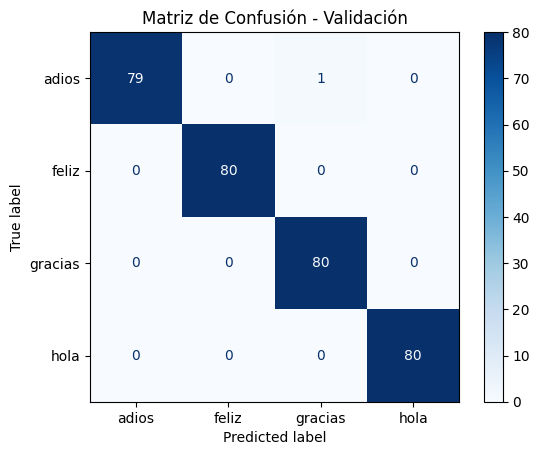


📊 Accuracy final - Entrenamiento: 0.98, Validación: 1.00
✅ Buen desempeño general


TypeError: cannot unpack non-iterable Sequential object

In [26]:
def train_model_from_npy(epochs=300):
    X, y, label_map = load_dataset()  # y debe ser one-hot con num_clases = len(label_map)
    print(f"✅ Total muestras: {X.shape[0]}, Clases: {len(label_map)}")
    # Sanity checks de shape/dtype (opcionales pero útiles)
    assert X.ndim == 3 and X.shape[1] == MODEL_FRAMES and X.shape[2] == LENGTH_KEYPOINTS, \
        f"X shape {X.shape} debe ser (N, {MODEL_FRAMES}, {LENGTH_KEYPOINTS})"
    assert y.ndim == 2, f"y debe ser one-hot (N, C); shape actual: {y.shape}"

    X = X.astype(np.float32)

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=np.argmax(y, axis=1)
    )

    model = get_model(MODEL_FRAMES, output_length=y.shape[1])
    print("MODEL in/out (entrenamiento):", model.input_shape, "->", model.output_shape)

    early_stop = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=1)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=8,
        callbacks=[early_stop],
        verbose=1
    )

    # --- GUARDAR MODELO COMPLETO (.h5) ---
    model.save(MODEL_PATH)
    print(f"💾 Modelo guardado en: {MODEL_PATH}")

 # 📊 Matriz de Confusión
    y_pred = model.predict(X_val)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_val, axis=1)

    cm = confusion_matrix(y_true, y_pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(label_map.keys()))
    disp.plot(cmap="Blues", values_format=".0f")
    plt.title("Matriz de Confusión - Validación")
    plt.show()

    # 📈 Diagnóstico
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    print(f"\n📊 Accuracy final - Entrenamiento: {train_acc:.2f}, Validación: {val_acc:.2f}")
    if abs(train_acc - val_acc) > 0.2:
        print("⚠️ Posible overfitting")
    elif max(history.history['val_accuracy']) < 0.6:
        print("⚠️ Posible underfitting")
    else:
        print("✅ Buen desempeño general")

    return model

model, label_map = train_model_from_npy(epochs=150)

## 5. Validaciones

In [27]:
LENGTH_KEYPOINTS = 126

def get_model(max_length_frames, output_length: int):
    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=(max_length_frames, LENGTH_KEYPOINTS), kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.5))
    model.add(LSTM(128, return_sequences=False, kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dense(output_length, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [28]:
MODEL_PATH = "models/action.h5"
DATA_PATH = "data/frases"
WORDS = sorted(os.listdir(DATA_PATH))  # nombres de las clases
MODEL_FRAMES = 30
MIN_LENGTH_FRAMES = 10
FONT = cv2.FONT_HERSHEY_SIMPLEX
FONT_POS = (10, 30)
FONT_SIZE = 1

def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    return model.process(image)

def there_hand(results):
    return results.left_hand_landmarks or results.right_hand_landmarks

def extract_keypoints(results):
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]) if results.left_hand_landmarks else np.zeros((21, 3))
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]) if results.right_hand_landmarks else np.zeros((21, 3))
    return np.concatenate([lh, rh]).flatten()

def normalize_keypoints(keypoints, target_length=30):
    current_length = len(keypoints)
    if current_length == target_length:
        return keypoints
    elif current_length > target_length:
        step = current_length / target_length
        indices = np.arange(0, current_length, step).astype(int)[:target_length]
        return [keypoints[i] for i in indices]
    else:
        indices = np.linspace(0, current_length - 1, target_length)
        interpolated = []
        for i in indices:
            lower = int(np.floor(i))
            upper = int(np.ceil(i))
            weight = i - lower
            if lower == upper:
                interpolated.append(keypoints[lower])
            else:
                interpolated.append(((1 - weight) * np.array(keypoints[lower]) + weight * np.array(keypoints[upper])).tolist())
        return interpolated

def draw_keypoints(image, results):
    mp_drawing = mp.solutions.drawing_utils
    if results.left_hand_landmarks:
        mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp.solutions.holistic.HAND_CONNECTIONS)
    if results.right_hand_landmarks:
        mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp.solutions.holistic.HAND_CONNECTIONS)

In [29]:
def evaluate_model(threshold=0.8, margin_frame=1, delay_frames=3, src=1):
    print("🟡 Cargando modelo...")
    model = load_model(MODEL_PATH)

    print("📷 Inicializando cámara...")
    cap = cv2.VideoCapture(src)
    if not cap.isOpened():
        print("❌ No se pudo abrir la cámara.")
        return

    sentence = []
    pred_label = ""
    pred_prob = 0.0
    kp_seq, count_frame, fix_frames = [], 0, 0
    recording = False

    with Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
        print("🎥 Traductor en vivo iniciado. Presiona 'q' para salir.")
        while True:
            ret, frame = cap.read()
            if not ret:
                print("⚠️ No se pudo leer el frame de la cámara.")
                break

            results = mediapipe_detection(frame, holistic)

            if there_hand(results) or recording:
                recording = False
                count_frame += 1
                if count_frame > margin_frame:
                    kp_frame = extract_keypoints(results)
                    kp_seq.append(kp_frame)
            else:
                if count_frame >= MIN_LENGTH_FRAMES + margin_frame:
                    fix_frames += 1
                    if fix_frames < delay_frames:
                        recording = True
                        continue

                    kp_seq = kp_seq[: -(margin_frame + delay_frames)]
                    kp_normalized = normalize_keypoints(kp_seq, target_length=MODEL_FRAMES)
                    input_data = np.expand_dims(np.array(kp_normalized), axis=0)

                    prediction = model.predict(input_data, verbose=0)[0]
                    max_idx = np.argmax(prediction)
                    max_prob = prediction[max_idx]

                    if max_prob > threshold:
                        pred_label = WORDS[max_idx]
                        pred_prob = max_prob * 100
                        sentence.insert(0, pred_label)

                kp_seq = []
                count_frame = 0
                fix_frames = 0
                recording = False

            # Mostrar texto y porcentaje en ventana
            cv2.rectangle(frame, (0, 0), (640, 60), (245, 117, 16), -1)
            cv2.putText(frame, f'{pred_label.upper()} ({pred_prob:.1f}%)', FONT_POS, FONT, FONT_SIZE, (255, 255, 255), 2)

            draw_keypoints(frame, results)
            cv2.imshow('Traductor LSP', frame)

            if cv2.waitKey(10) & 0xFF == ord('q'):
                print("🛑 Cerrando traductor.")
                break

        cap.release()
        cv2.destroyAllWindows()

if __name__ == "__main__":
    evaluate_model()

🟡 Cargando modelo...
📷 Inicializando cámara...
🎥 Traductor en vivo iniciado. Presiona 'q' para salir.
🛑 Cerrando traductor.


In [30]:
from contextlib import contextmanager
def evaluate_video(
    video_path: str,
    threshold: float = 0.8,
    margin_frame: int = 1,
    delay_frames: int = 3,
    output: bool = True,
    show_window: bool = False,
):
    """
    Evalúa un video en archivo en lugar de la cámara.
    - Detecta ventanas de gesto (aparece mano -> desaparece) y predice con el modelo.
    - Genera un MP4 anotado con el texto (si output=True).
    - Devuelve una lista de detecciones con tiempos de inicio/fin y probabilidad.
    """
    if not os.path.isfile(video_path):
        print(f"❌ No existe el archivo: {video_path}")
        return []

    print("🟡 Cargando modelo...")
    model = load_model(MODEL_PATH)

    print(f"🎬 Abriendo video: {video_path}")
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("❌ No se pudo abrir el video.")
        return []

    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)  or 640)
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or 480)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)

    # Preparar salida de video
    writer = None
    out_path = None
    if output:
        base = os.path.splitext(os.path.basename(video_path))[0]
        out_path = f"resultado_{base}.mp4"
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(out_path, fourcc, fps, (width, height))

    detections = []  # cada item: {label, prob, start_frame, end_frame, start_time, end_time}

    kp_seq, count_frame, fix_frames = [], 0, 0
    recording = False

    pred_label = ""
    pred_prob = 0.0
    overlay_cooldown = 0  # frames para mostrar el texto en el video

    # --- MediaPipe Holistic context manager (usa tu helper si lo tienes) ---
    import mediapipe as mp
    with mp.solutions.holistic.Holistic(
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as holistic:

        frame_idx = 0
        print("▶️ Procesando frames...")
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            # Detección con tu helper (si ya lo tienes). Si no, usa el pipeline normal de MP:
            # results = mediapipe_detection(frame, holistic)
            # Si tu mediapipe_detection ya convierte a RGB y llama holistic.process, úsalo.
            # Aquí uso el helper por compatibilidad con tu notebook:
            results = mediapipe_detection(frame, holistic)

            if there_hand(results) or recording:
                recording = False
                count_frame += 1
                if count_frame > margin_frame:
                    kp_frame = extract_keypoints(results)  # Debe regresar vector de 126 (o lo que uses)
                    kp_seq.append(kp_frame)
            else:
                # Sección de cierre del gesto
                if count_frame >= MIN_LENGTH_FRAMES + margin_frame:
                    fix_frames += 1
                    if fix_frames < delay_frames:
                        recording = True
                        # seguimos acumulando el "colchón" de cierre
                    else:
                        # recorta margen + delay
                        if margin_frame + delay_frames > 0:
                            kp_seq = kp_seq[:-(margin_frame + delay_frames)] if len(kp_seq) > (margin_frame + delay_frames) else kp_seq

                        # normaliza y remuestrea a MODEL_FRAMES
                        kp_normalized = normalize_keypoints(kp_seq, target_length=MODEL_FRAMES)  # (30, D)
                        input_data = np.expand_dims(np.array(kp_normalized), axis=0)            # (1,30,D)

                        prediction = model.predict(input_data, verbose=0)[0]
                        max_idx = int(np.argmax(prediction))
                        max_prob = float(prediction[max_idx])

                        if max_prob > threshold:
                            pred_label = WORDS[max_idx]
                            pred_prob = max_prob * 100.0
                            overlay_cooldown = int(fps * 0.7)  # muestra ~0.7s el texto

                            # marca temporal (aprox): usamos frame actual como fin, y restamos la duración de la ventana
                            end_frame = frame_idx
                            dur_frames = len(kp_seq)
                            start_frame = max(0, end_frame - dur_frames)
                            detections.append({
                                "label": pred_label,
                                "prob": pred_prob,
                                "start_frame": start_frame,
                                "end_frame": end_frame,
                                "start_time": start_frame / fps,
                                "end_time": end_frame / fps,
                            })

                        # reset para siguiente gesto
                        kp_seq, count_frame, fix_frames, recording = [], 0, 0, False
                else:
                    # No hubo suficiente material para formar gesto
                    kp_seq, count_frame, fix_frames, recording = [], 0, 0, False

            # --- Overlay de texto (si hubo predicción reciente) ---
            if overlay_cooldown > 0:
                cv2.rectangle(frame, (0, 0), (max(300, width // 2), 60), (245, 117, 16), -1)
                cv2.putText(frame, f'{pred_label.upper()} ({pred_prob:.1f}%)',
                            (20, 40), FONT, FONT_SIZE, (255, 255, 255), 2)
                overlay_cooldown -= 1

            # Dibuja keypoints si quieres mantener tu visualización
            try:
                draw_keypoints(frame, results)
            except Exception:
                pass  # por si tu helper no está cargado aquí

            # Escribir/frame y/o mostrar
            if writer is not None:
                writer.write(frame)

            if show_window:
                cv2.imshow('Traductor LSP (video)', frame)
                if cv2.waitKey(1) & 0xFF == ord('q'):
                    break

            frame_idx += 1

    cap.release()
    if writer is not None:
        writer.release()
    if show_window:
        cv2.destroyAllWindows()

    # --- Resumen ---
    print("✅ Detecciones:")
    if not detections:
        print("   (sin resultados sobre el umbral)")
    else:
        for i, d in enumerate(detections, 1):
            print(f" {i:02d}. {d['label']}  {d['prob']:.1f}%  "
                  f"{d['start_time']:.2f}s → {d['end_time']:.2f}s  "
                  f"(frames {d['start_frame']}–{d['end_frame']})")

    if out_path:
        print(f"💾 Video anotado: {out_path}")

    return detections

In [31]:
detecciones = evaluate_video(
    "prueba.mp4",   # ruta a tu video
    threshold=0.8,   # probabilidad mínima aceptada
    output=True,     # genera un video anotado
    show_window=False # pon True si quieres que se abra una ventana en vivo
)

print(detecciones)

🟡 Cargando modelo...
🎬 Abriendo video: prueba.mp4
▶️ Procesando frames...
✅ Detecciones:
 01. hola  99.9%  1.33s → 2.66s  (frames 40–80)
 02. hola  99.9%  4.02s → 5.28s  (frames 121–159)
 03. feliz  99.9%  6.57s → 8.80s  (frames 198–265)
 04. adios  99.9%  9.92s → 11.68s  (frames 299–352)
 05. adios  99.9%  12.58s → 13.94s  (frames 379–420)
 06. gracias  100.0%  14.97s → 16.16s  (frames 451–487)
 07. gracias  100.0%  16.99s → 18.69s  (frames 512–563)
💾 Video anotado: resultado_prueba.mp4
[{'label': 'hola', 'prob': 99.93089437484741, 'start_frame': 40, 'end_frame': 80, 'start_time': 1.3276146179401993, 'end_time': 2.6552292358803986}, {'label': 'hola', 'prob': 99.91962313652039, 'start_frame': 121, 'end_frame': 159, 'start_time': 4.016034219269103, 'end_time': 5.277268106312293}, {'label': 'feliz', 'prob': 99.94334578514099, 'start_frame': 198, 'end_frame': 265, 'start_time': 6.571692358803987, 'end_time': 8.79544684385382}, {'label': 'adios', 'prob': 99.91087317466736, 'start_frame': 2